<a href="https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/https%2Fgithub.com%2Faminsiddik2810%2Fdata-science-2026.git/Pertemuan_9_AminSiddikRangkuti_220401010124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science — Pertemuan 9: Algoritma Klasifikasi (Bagian 1)

## Identitas Mahasiswa

**Nama:** Amin Siddik Rangkuti  
**NIM:** 220401010124  
**Kelas:** IF405  
**Program Studi:** PJJ Informatika  
**Mata Kuliah:** Data Science  
**Universitas:** Universitas Siber Asia

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/main/Pertemuan_9_AminSiddikRangkuti_220401010124.ipynb)

## 1. Tujuan Praktikum

Notebook ini dibuat untuk aktivitas hands-on Pertemuan 9 Data Science tentang algoritma klasifikasi.  
Tujuan praktikum:

1. Memahami konsep klasifikasi sebagai bagian dari supervised learning.
2. Menerapkan Logistic Regression untuk prediksi diagnosis.
3. Menerapkan Decision Tree untuk prediksi diagnosis.
4. Mengevaluasi model menggunakan confusion matrix, accuracy, precision, recall, dan F1-score.
5. Membandingkan hasil Logistic Regression dan Decision Tree.

## 2. Konsep Singkat Klasifikasi

Klasifikasi adalah metode machine learning untuk memprediksi kelas atau kategori diskret.  
Contoh klasifikasi:

- Email: spam atau bukan spam.
- Diagnosis medis: positif atau negatif.
- Transaksi: fraud atau normal.
- Kelulusan: lulus atau tidak lulus.

Pada praktikum ini digunakan dataset **Breast Cancer Wisconsin** dari `sklearn.datasets`. Target klasifikasi terdiri dari dua kelas, sehingga termasuk **binary classification**.

In [18]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

## 3. Load Dataset

Dataset yang digunakan adalah **Breast Cancer Wisconsin**.  
Dataset ini berisi fitur hasil pemeriksaan medis untuk memprediksi apakah diagnosis termasuk kelas **malignant** atau **benign**.

In [19]:
# Load dataset
data = load_breast_cancer()

# Membuat DataFrame fitur
df = pd.DataFrame(data.data, columns=data.feature_names)

# Menambahkan kolom target
df["target"] = data.target

# Menampilkan 5 data pertama
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [20]:
# Informasi dataset
print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", len(data.feature_names))
print("Nama kelas:", data.target_names)
print("\nDistribusi target:")
print(df["target"].value_counts())

Jumlah data: 569
Jumlah fitur: 30
Nama kelas: ['malignant' 'benign']

Distribusi target:
target
1    357
0    212
Name: count, dtype: int64


Keterangan target:

- `0` = malignant
- `1` = benign

## 4. Menentukan Fitur dan Target

Pada bagian ini, data dipisahkan menjadi:

- `X` = fitur input.
- `y` = target atau label diagnosis.

In [21]:
X = df.drop("target", axis=1)
y = df["target"]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (569, 30)
Ukuran y: (569,)


## 5. Membagi Data Training dan Testing

Data dibagi menjadi data latih dan data uji.  
Proporsi yang digunakan:

- 80% data training
- 20% data testing

Parameter `stratify=y` digunakan agar proporsi kelas pada data training dan testing tetap seimbang.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Data training: (455, 30)
Data testing: (114, 30)


## 6. Standardisasi Data

Logistic Regression membutuhkan skala fitur yang seimbang agar proses pelatihan model lebih stabil.  
Oleh karena itu, fitur distandardisasi menggunakan `StandardScaler`.

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Model 1: Logistic Regression

Logistic Regression digunakan untuk klasifikasi dengan menghasilkan probabilitas kelas.  
Threshold default yang digunakan adalah 0.5.

In [24]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Melatih model
log_reg.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = log_reg.predict(X_test_scaled)

# Probabilitas kelas positif
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [25]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=data.target_names))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



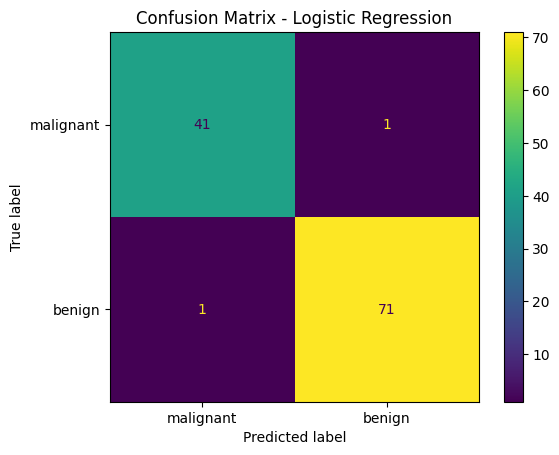

In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=data.target_names)
disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 8. Model 2: Decision Tree

Decision Tree adalah algoritma klasifikasi berbentuk pohon keputusan.  
Model ini mudah dipahami karena menggunakan aturan bercabang seperti pertanyaan ya/tidak.

In [27]:
tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

# Melatih model
tree_model.fit(X_train, y_train)

# Prediksi
y_pred_tree = tree_model.predict(X_test)

In [28]:
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

Classification Report - Decision Tree
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



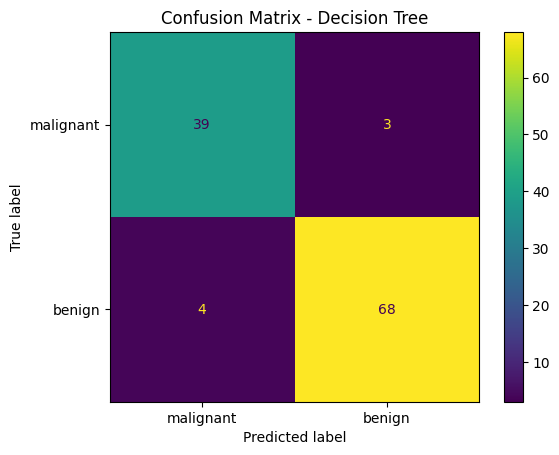

In [29]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=data.target_names)
disp_tree.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## 9. Visualisasi Decision Tree

Visualisasi berikut menunjukkan struktur pohon keputusan yang digunakan oleh model Decision Tree.

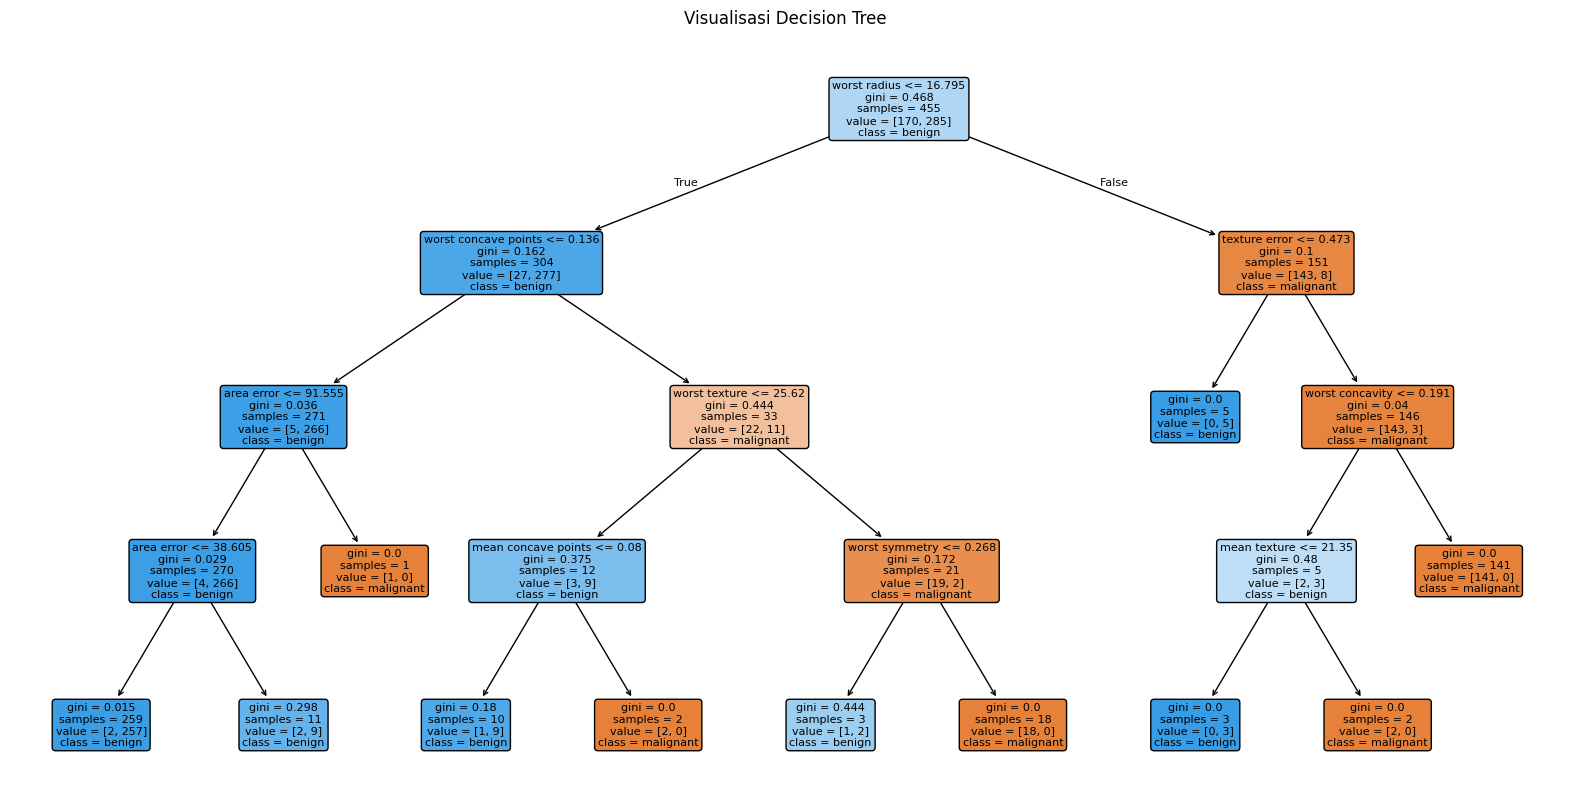

In [30]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Visualisasi Decision Tree")
plt.show()

## 10. Perbandingan Evaluasi Model

Metrik evaluasi yang digunakan:

- **Accuracy**: seberapa banyak prediksi yang benar dari seluruh data.
- **Precision**: seberapa tepat model saat memprediksi kelas positif.
- **Recall**: seberapa baik model menemukan seluruh data positif.
- **F1-score**: rata-rata harmonis antara precision dan recall.

In [31]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_lr),
    evaluate_model("Decision Tree", y_test, y_pred_tree)
])

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.938596,0.957746,0.944444,0.951049


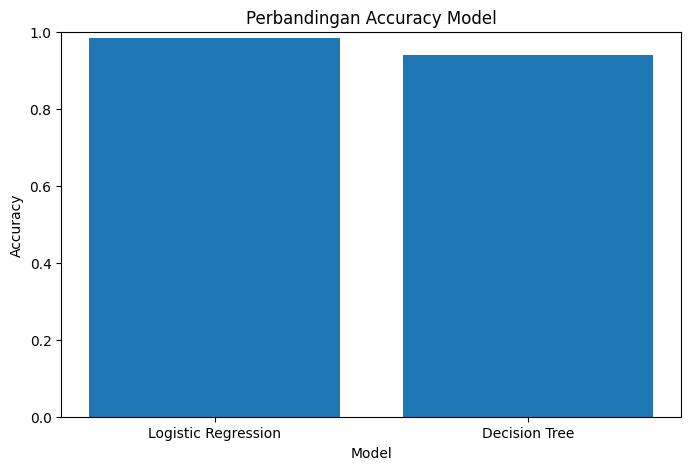

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0, 1)
plt.title("Perbandingan Accuracy Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

## 11. Uji Threshold pada Logistic Regression

Threshold default Logistic Regression adalah 0.5.  
Pada kasus medis, threshold dapat diubah untuk menyesuaikan kebutuhan precision dan recall.

In [16]:
# Mengubah threshold menjadi 0.3
threshold = 0.3
y_pred_lr_threshold = (y_proba_lr >= threshold).astype(int)

print("Classification Report - Logistic Regression dengan Threshold 0.3")
print(classification_report(y_test, y_pred_lr_threshold, target_names=data.target_names))

Classification Report - Logistic Regression dengan Threshold 0.3
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



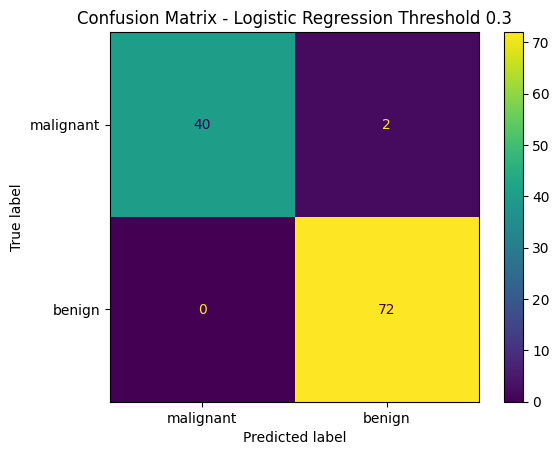

In [17]:
cm_lr_th = confusion_matrix(y_test, y_pred_lr_threshold)

disp_lr_th = ConfusionMatrixDisplay(confusion_matrix=cm_lr_th, display_labels=data.target_names)
disp_lr_th.plot()
plt.title("Confusion Matrix - Logistic Regression Threshold 0.3")
plt.show()

## 12. Interpretasi Hasil

Berdasarkan hasil praktikum:

1. Logistic Regression dapat digunakan untuk klasifikasi diagnosis karena menghasilkan probabilitas kelas.
2. Decision Tree dapat digunakan untuk membuat keputusan klasifikasi yang mudah dijelaskan.
3. Confusion Matrix membantu melihat jumlah prediksi benar dan salah pada tiap kelas.
4. Accuracy menunjukkan ketepatan umum model.
5. Precision, Recall, dan F1-Score penting untuk mengevaluasi performa model, khususnya pada kasus diagnosis medis.
6. Perubahan threshold dapat memengaruhi hasil prediksi, terutama trade-off antara precision dan recall.

**Metrik yang paling relevan:** pada kasus diagnosis, recall penting karena membantu mengurangi kasus positif yang terlewat (False Negative). Accuracy tetap dilihat, tetapi perlu dibaca bersama precision, recall, F1-Score, dan Confusion Matrix.

## 14. Referensi

1. Modul Pembelajaran Pengantar Data Science Pertemuan 9 - Algoritma Klasifikasi Bagian 1.
2. Dokumentasi Scikit-Learn: Logistic Regression.
3. Dokumentasi Scikit-Learn: Decision Tree Classifier.
4. Dataset Breast Cancer Wisconsin dari Scikit-Learn.

## Kesimpulan

Pada Pertemuan 9, saya mempelajari penerapan **Logistic Regression** dan **Decision Tree** untuk klasifikasi serta cara mengevaluasi model menggunakan **Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score**. Hasil praktikum menunjukkan bahwa kedua model dapat digunakan untuk memprediksi kelas diagnosis, tetapi performanya perlu dibandingkan berdasarkan beberapa metrik, bukan hanya accuracy.

Untuk kasus diagnosis, **recall** menjadi metrik yang penting karena kesalahan melewatkan kasus yang seharusnya terdeteksi dapat memiliki dampak besar. Precision dan F1-Score tetap digunakan sebagai pendamping agar evaluasi lebih seimbang.

**Keterbatasan:** praktikum menggunakan dataset bawaan Scikit-Learn dan belum membahas validasi eksternal, tuning hyperparameter yang luas, atau penerapan pada data klinis nyata. Pertanyaan lanjutan yang dapat dipelajari adalah bagaimana perubahan threshold dan hyperparameter memengaruhi keseimbangan precision dan recall.